# AlpsML · UV models of ALPs with XGBoost + SHAP + MCMC

## Physics motivation

**Axion-like particles (ALPs)** arise from the spontaneous breaking of a global
U(1)<sub>PQ</sub> symmetry at a scale f<sub>a</sub>. In a UV-complete model the
ALP couplings to the SM particles are **not free parameters**: they are fully
fixed by the **Peccei–Quinn (PQ) charges** assigned to the SM fermions.

The map from the UV charges to the observable IR couplings follows two rules:

1. **Fermion couplings**: equal to the PQ charge of the corresponding fermion
   (up to a sign coming from the Yukawa structure).
2. **Gauge-boson couplings** (gluons, photons, W/Z): linear combinations of the
   PQ charges, fixed by the **chiral anomaly coefficients** of the PQ current
   with each gauge group:

$$
g_{aGG} \propto \sum_f T(R_f)\,Q_f^{\rm PQ}, \qquad
g_{a\gamma\gamma} \propto \sum_f Q_f^{\rm em,2}\,Q_f^{\rm PQ}.
$$

This is what `alpaca` implements through `PQChargedModel.get_couplings`: given the
5 PQ-charge parameters and f<sub>a</sub> it automatically computes the full set of
IR couplings, which are then used to evaluate the χ² over the meson transitions.

### Non-universal model

The charges are **generation-dependent** for the SU(2)<sub>L</sub> doublets: only
the **third generation** of q<sub>L</sub> and l<sub>L</sub> carries a non-zero PQ
charge, while the right-handed singlets (u<sub>R</sub>, d<sub>R</sub>,
e<sub>R</sub>) are generation-universal:

```python
from alpaca.uvmodels import PQChargedModel

model = PQChargedModel('non-universal model', {
    'qL': [0, 0, pq_qL],   # left-handed quark doublet: charge only in 3rd gen
    'lL': [0, 0, pq_lL],   # left-handed lepton doublet: charge only in 3rd gen
    'uR': pq_uR,            # right-handed up singlet: universal
    'dR': pq_dR,            # right-handed down singlet: universal
    'eR': pq_eR,            # right-handed charged singlet: universal
})
couplings = model.get_couplings({}, 4 * np.pi * fa)
```

The explored parameter space is therefore **7-dimensional**: the 5 PQ charges,
`log_fa`, and the ALP mass `ma` (a free parameter in this v2 of the analysis):
`log_fa`, `pq_qL`, `pq_lL`, `pq_uR`, `pq_dR`, `pq_eR`, `ma`.

---

## Pipeline

1. **χ² dataset**: 8 000 points sampled with a 7-D Latin Hypercube over the 5 PQ
   charges, `log_fa` and `ma`. For each point a `PQChargedModel` is built, the IR
   couplings are obtained via `get_couplings`, and the **combined χ²** over the
   full `alpaca` observable sector (`'all'`) is evaluated. Parallelized with
   `multiprocessing.Pool`, with a backup every 500 points. The training target is
   a sigmoid of the **Δχ²** relative to the dataset minimum.
2. **XGBoost — two surrogates** (following the `alpaca` tutorial): a
   **classifier** (CLF) of the sigmoid target over the whole space (the
   allowed/excluded boundary), and a **regressor** (REG) of the raw χ² trained
   only inside the allowed region. Each is tuned with Optuna (shallow trees,
   strong regularization).
3. **SHAP**: `Permutation Explainer` on the classifier surrogate. Beeswarm, bar,
   waterfall and dependence plots to see which PQ charges drive the
   phenomenology.
4. **MCMC**: 128 walkers with `emcee` over the surrogates; the likelihood comes
   from the χ² **regressor** and the classifier acts as a soft wall. Runs until
   the autocorrelation time converges, then a `corner` plot of the posterior.

### Caches

The two heavy stages (dataset generation and training) are **gated**: they run
only if the file does not exist **or** if you set the corresponding flag to
`True` in the Setup block (`FORCE_REGENERATE`, `FORCE_RETRAIN`, `FORCE_MCMC`).

## Index

| §   | Section                              | Cache                                                  | Approx. cost |
|-----|--------------------------------------|--------------------------------------------------------|--------------|
| [Setup](#setup)        | Imports, paths, flags     | —                                                      | <1 s |
| [§1](#sec-1)           | χ² dataset generation     | `outputs/paper/datasets/dataset_alps_uv_v2.csv`        | minutes (8 000 evals × `alpaca`, ~1.6 s each ÷ N cores) |
| [§2](#sec-2)           | Dataset inspection        | —                                                      | <1 s |
| [§3](#sec-3)           | XGBoost training (Optuna) | `outputs/paper/models/modelo_alps_{clf,reg}_v2.json`   | ~5–10 min (CLF 100 + REG 80 Optuna trials) |
| [§4](#sec-4)           | SHAP interpretability     | —                                                      | ~30 s |
| [§5](#sec-5)           | MCMC posterior + corner   | `outputs/paper/datasets/posterior_samples_uv_v2.csv`   | minutes (128 walkers, run to autocorrelation convergence) |


## <a id="setup"></a>Setup (run first)

Defines the paths via `pathlib`, creates the output directories if they do not
exist, and sets the `FORCE_REGENERATE` / `FORCE_RETRAIN` / `FORCE_MCMC` flags. It
also caps BLAS to 1 thread per process (the dataset generation parallelizes by
hand with `multiprocessing.Pool`). The key physics settings live here too: the PQ
charges range over `[-1, 1]` and the ALP mass is scanned in the window
`[1.5, 2.5]` GeV.

In [7]:
import os

# BLAS: 1 thread per process (the pool handles parallelism)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from pathlib import Path

# Paths
ROOT = Path.cwd().parent
PAPER_DIR    = Path.home() / "alejandro" / "alpsml"
DATASETS_DIR = PAPER_DIR / "datasets"
MODELS_DIR   = PAPER_DIR / "models"
FIGURES_DIR  = PAPER_DIR / "figures"
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

DATASET_CSV          = DATASETS_DIR / "dataset_alps_uv_v2.csv"
DATASET_BACKUP       = DATASETS_DIR / "backup_dataset_alps_uv_v2.csv"

# Two surrogates: CLF = sigmoid(chi2) wall, REG = raw chi2 in the allowed region
CLF_PATH        = MODELS_DIR / "modelo_alps_clf_v2.json"
REG_PATH        = MODELS_DIR / "modelo_alps_reg_v2.json"
BEST_PARAMS_CLF = MODELS_DIR / "best_params_clf_v2.json"
BEST_PARAMS_REG = MODELS_DIR / "best_params_reg_v2.json"

POSTERIOR_CSV        = DATASETS_DIR / "posterior_samples_uv_v2.csv"
POSTERIOR_CSV_THEORY = DATASETS_DIR / "posterior_samples_uv_v2_theory.csv"
CORNER_PNG           = FIGURES_DIR  / "corner_plot_uv_v2.png"
CORNER_PHYS_PNG      = FIGURES_DIR  / "corner_plot_uv_v2_phys.png"

# Allowed region: Delta-chi2 = CUTOFF above the minimum (not an absolute chi2)
CUTOFF        = 10.0
SIGMOID_WIDTH = 0.4

# Cap at 16 cores for the cluster
N_CORES = 16

# False reuses the on-disk caches; set True to recompute a stage
FORCE_REGENERATE = False
FORCE_RETRAIN    = False
FORCE_MCMC       = False

# PQ charges in [-1, 1]; ALP mass window in GeV
PQ_MIN = -1.0
PQ_MAX =  1.0
MA_MIN = 1.5
MA_MAX = 2.5

FEATURES = ["log_fa", "pq_qL", "pq_lL", "pq_uR", "pq_dR", "pq_eR", "ma"]

print("Setup OK")
print(f"  ROOT       = {ROOT}")
print(f"  cores      = {N_CORES}")
print(f"  ma window  = [{MA_MIN}, {MA_MAX}] GeV   |   PQ in [{PQ_MIN}, {PQ_MAX}]")
print(f"  dataset    = {DATASET_CSV} ({'exists' if DATASET_CSV.exists() else 'missing'})")
print(f"  clf model  = {CLF_PATH} ({'exists' if CLF_PATH.exists() else 'missing'})")
print(f"  reg model  = {REG_PATH} ({'exists' if REG_PATH.exists() else 'missing'})")
print(f"  posterior  = {POSTERIOR_CSV} ({'exists' if POSTERIOR_CSV.exists() else 'missing'})")
print(f"  FORCE_REGENERATE={FORCE_REGENERATE}  FORCE_RETRAIN={FORCE_RETRAIN}  FORCE_MCMC={FORCE_MCMC}")

Setup OK
  ROOT       = /home/aleja/repos/PhysicsML/AlpsML
  cores      = 24
  ma window  = [1.5, 2.5] GeV   |   PQ in [-1.0, 1.0]
  dataset    = /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/datasets/dataset_alps_uv_v2.csv (exists)
  clf model  = /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/models/modelo_alps_clf_v2.json (exists)
  reg model  = /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/models/modelo_alps_reg_v2.json (exists)
  posterior  = /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/datasets/posterior_samples_uv_v2.csv (exists)
  FORCE_REGENERATE=False  FORCE_RETRAIN=False  FORCE_MCMC=False


## <a id="sec-1"></a>§1. χ² dataset generation

### Building the UV model

For each point in parameter space a non-universal `PQChargedModel` is
instantiated. The 5 PQ-charge parameters automatically determine all the IR
couplings of the ALP:

- **Fermion couplings**: proportional to the PQ charge of the fermion (with a
  sign that depends on whether the field transforms left- or right-handedly
  under the PQ symmetry).
- **Gluon and photon couplings**: computed by `alpaca` from the anomaly
  coefficients of the PQ current, which are weighted sums of the PQ charges of
  all coloured/charged fermions.

The specific non-universal model is:

```
'qL': [0, 0, pq_qL]  →  only the 3rd generation of the left-handed quark doublet carries PQ charge
'lL': [0, 0, pq_lL]  →  only the 3rd generation of the left-handed lepton doublet carries PQ charge
'uR': pq_uR           →  right-handed up singlet: universal charge across the 3 generations
'dR': pq_dR           →  right-handed down singlet: universal charge across the 3 generations
'eR': pq_eR           →  right-handed charged singlet: universal charge across the 3 generations
```

The call `model.get_couplings({}, 4*np.pi*fa)` returns the couplings at the high
scale (4π·f<sub>a</sub>); `get_chi2` then runs them down (RGE) to the relevant low
scale before evaluating the observables of each transition. (Skipping the RGE
would bias the χ² by factors of ×2–×16, so the running is left **on**.)

### Sampling and χ²

A **7-dimensional** Latin Hypercube over
$(\log f_a,\; p_{qL},\; p_{lL},\; p_{uR},\; p_{dR},\; p_{eR},\; m_a)$
with `scipy.stats.qmc.LatinHypercube`: `log_fa ∈ [6, 8]`, the PQ charges in
`[-1, 1]`, and the ALP mass `ma ∈ [1.5, 2.5]` GeV.

For each point the **combined χ²** is evaluated over the **full `alpaca`
observable sector** (`default_sectors['all']`) — not just a handful of
transitions. It includes the FCNC meson decays ($K\to a\pi$, $B\to K a$,
$B\to a\pi$, …) but also visible channels such as $B\to K\mu\mu$, meson mixing
($\Delta m_B$, $\epsilon_K$, …) and radiative/leptonic decays, as is appropriate
for a realistic ~2 GeV ALP whose visible/invisible signature is experiment
dependent.

The χ² is computed as `get_chi2(...).chi2_tot()[0]`. `chi2_tot()` **automatically
excludes** observables that are NaN at a given point (channels kinematically
closed or undefined there — e.g. $a\to\tau\tau$ only constrains if $m_a>2m_\tau$);
there is **no** manual `np.nansum`.

The training target is a **sigmoid of the Δχ² relative to the dataset minimum**,
$1/(1 + e^{(\chi^2 - \chi^2_{\min} - 10)/0.4})$: ~1 for very allowed points
(χ² near the minimum) and ~0 for very excluded points (Δχ² ≫ 10). The boundary
sits at **Δχ² ≈ 10 above the best fit**, not at an absolute χ² value.

**Regenerated only if** `FORCE_REGENERATE = True` **or** if
`dataset_alps_uv_v2.csv` does not exist. Backup every 500 points.

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import qmc
import alpaca
import alpaca.sectors as _alpaca_sectors
from alpaca.uvmodels import PQChargedModel
from alpaca.statistics import get_chi2
import warnings
from tqdm.auto import tqdm
import multiprocessing as mp

# chi2 over the full 'all' observable sector; chi2_tot() drops NaN observables.
# get_couplings returns high-scale couplings (4*pi*fa); get_chi2 runs the RGE down.
N_PUNTOS = 8_000

# 7D space: (log_fa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma)
L_BOUNDS_GEN = [6.0, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, MA_MIN]
U_BOUNDS_GEN = [8.0, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, MA_MAX]

# Full 'all' observable sector
try:
    TRANSICIONES_TARGET = _alpaca_sectors.default_sectors['all']
    _n_obs = len(list(TRANSICIONES_TARGET.observables))
    print(f"Using the full 'all' sector: {_n_obs} observables")
except Exception as _exc:
    warnings.warn(f"Could not load alpaca.sectors: {_exc}. Using a minimal list.")
    TRANSICIONES_TARGET = [
        "K+ -> alp pion+", "KL -> alp pion0",
        "B+ -> K+ alp", "B0 -> K0 alp", "B+ -> alp pion+",
    ]

# 'fork' so workers can see the functions defined here
try:
    mp.set_start_method('fork', force=True)
except RuntimeError:
    pass
_MP_CTX = mp.get_context('fork')

def obtener_chi2_uv(p):
    """Global UV chi2 for a 7D point (log_fa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma)."""
    logfa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma = p
    fa = 10**logfa
    fa_scale = 4 * np.pi * fa
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        uv_model = PQChargedModel('non-universal model', {
            'qL': [0, 0, pq_qL],
            'lL': [0, 0, pq_lL],
            'uR': pq_uR,
            'dR': pq_dR,
            'eR': pq_eR,
        })
        c = uv_model.get_couplings({}, fa_scale)
        chi2 = get_chi2(TRANSICIONES_TARGET, ma, c, fa)
        return float(chi2.chi2_tot()[0])

def procesar_punto_paralelo(args):
    i, p = args
    try:
        chi_val = obtener_chi2_uv(p)
        return {
            'log_fa': p[0], 'pq_qL': p[1], 'pq_lL': p[2],
            'pq_uR': p[3], 'pq_dR': p[4], 'pq_eR': p[5], 'ma': p[6],
            'chi2': chi_val,
        }
    except Exception as e:
        return {"error": f"Point {i}: {e}"}

if not FORCE_REGENERATE and DATASET_CSV.exists():
    print(f"Dataset already at {DATASET_CSV} ({DATASET_CSV.stat().st_size/1e6:.1f} MB) -- using cache.")
    print("Set FORCE_REGENERATE=True in Setup to regenerate.")
elif __name__ == '__main__':
    sampler_lhs = qmc.LatinHypercube(d=7)
    puntos = qmc.scale(sampler_lhs.random(n=N_PUNTOS), L_BOUNDS_GEN, U_BOUNDS_GEN)
    tareas = list(enumerate(puntos))
    print(f"Parallel run | points: {N_PUNTOS} | cores: {N_CORES} | ~{N_PUNTOS*1.6/N_CORES/60:.0f} min")
    dataset = []
    n_errors = 0
    with _MP_CTX.Pool(processes=N_CORES, maxtasksperchild=1000) as pool:
        try:
            for resultado in tqdm(
                pool.imap_unordered(procesar_punto_paralelo, tareas, chunksize=2),
                total=N_PUNTOS, desc="Progress"
            ):
                if resultado is not None:
                    if "error" in resultado:
                        n_errors += 1
                        if n_errors <= 5 or n_errors % 500 == 0:
                            print(f"\n[!] {resultado['error']}")
                    else:
                        dataset.append(resultado)
                if len(dataset) > 0 and len(dataset) % 500 == 0:
                    pd.DataFrame(dataset).to_csv(DATASET_BACKUP, index=False)
                    print(f"  Backup: {len(dataset)} valid points ({n_errors} errors)")
        except Exception as pool_err:
            print(f"\n[Pool error] {pool_err} — saving what we have...")
    print(f"\nLoop finished: {len(dataset)} valid points, {n_errors} errors")
    if dataset:
        df = pd.DataFrame(dataset)
        # Drop non-finite chi2 before calibrating the cut
        n_before = len(df)
        df = df[np.isfinite(df['chi2'])].reset_index(drop=True)
        if len(df) < n_before:
            print(f"  Dropped {n_before - len(df)} points with non-finite chi2")
        # Sigmoid target relative to the minimum (Delta-chi2)
        chi2_min = float(df['chi2'].min())
        df['target'] = 1 / (1 + np.exp((df['chi2'] - chi2_min - CUTOFF) / SIGMOID_WIDTH))
        df.to_csv(DATASET_CSV, index=False)
        print(f"chi2_min = {chi2_min:.2f}  ->  allowed region: chi2 < {chi2_min + CUTOFF:.2f}")
        print(f"Saved: {DATASET_CSV}  ({len(df)} rows)")

Using the full 'all' sector: 112 observables
Dataset already at /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/datasets/dataset_alps_uv_v2.csv (1.3 MB) -- using cache.
Set FORCE_REGENERATE=True in Setup to regenerate.


## <a id="sec-2"></a>§2. Dataset inspection

Descriptive statistics of the χ² and a count of points by the sigmoid target:

- **Allowed** (target > 0.8): region allowed by the meson observables.
- **Excluded** (target < 0.2): excluded region.
- **Boundary** (0.2 ≤ target ≤ 0.8): points on the transition curve — the most informative ones for the surrogate.

In [9]:
import pandas as pd

df = pd.read_csv(DATASET_CSV)
print("--- Chi2 statistics ---")
print(df['chi2'].describe())

permitidos = len(df[df['target'] > 0.8])
excluidos  = len(df[df['target'] < 0.2])
frontera   = len(df[(df['target'] >= 0.2) & (df['target'] <= 0.8)])

print(f"\nAllowed  (target ~1): {permitidos}")
print(f"Excluded (target ~0): {excluidos}")
print(f"Boundary:            {frontera}")

--- Chi2 statistics ---
count    8.000000e+03
mean     3.017934e+09
std      3.389314e+10
min      1.232610e+01
25%      1.891741e+01
50%      2.763576e+04
75%      8.146221e+06
max      1.240599e+12
Name: chi2, dtype: float64

Allowed  (target ~1): 2695
Excluded (target ~0): 5300
Boundary:            5


## <a id="sec-3"></a>§3. XGBoost training — two surrogates

Following the official `alpaca` tutorial
([Jorge-Alda/comcha_tutorial](https://github.com/Jorge-Alda/comcha_tutorial)),
**two** models with distinct roles are trained:

| Model | Target | Data | Role in the MCMC |
|--------|--------|-------|----------------|
| **CLF** (classifier) | $\mathrm{sigmoid}(\chi^2)$ | the whole space | **wall**: penalizes the excluded region |
| **REG** (regressor) | **raw** $\chi^2$ | only $\chi^2 < \chi^2_{\min}+10$ | **likelihood**: $\log L = -\tfrac12\,\chi^2$ |

The key point (a fix over the previous version): the **likelihood** comes from the
**raw-$\chi^2$ regressor**, not from the sigmoid. The sigmoid only defines the
allowed/excluded boundary and is used as a wall so the walkers do not wander into
the region where the regressor extrapolates. Sampling `log(sigmoid)` directly — as
was done before — gives a flat plateau and a "boxy" corner plot.

The classifier up-weights the excluded/boundary points (target ≤ 0.8) by ×5 so the
boundary is not ignored. Each model is tuned with Optuna (shallow trees, strong
regularization) and cached in `outputs/paper/models/`. **Retrains only if**
`FORCE_RETRAIN = True` **or** if the `.json` files are missing.

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import sklearn.metrics
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Two surrogates: CLF = sigmoid(chi2) over the whole space (allowed/excluded),
# REG = raw chi2 in the allowed region. MCMC uses log L = -0.5*REG and CLF as a wall.
features = FEATURES  # 7D

df = pd.read_csv(DATASET_CSV)
df = df[np.isfinite(df['chi2'])].reset_index(drop=True)
chi2_min = float(df['chi2'].min())

# Sigmoid target relative to the minimum (robust to old CSVs)
df['target'] = 1.0 / (1.0 + np.exp((df['chi2'] - chi2_min - CUTOFF) / SIGMOID_WIDTH))

allowed_mask = df['chi2'] < (chi2_min + CUTOFF)
print(f"chi2_min = {chi2_min:.2f}  |  allowed region (chi2 < {chi2_min + CUTOFF:.2f}): "
      f"{int(allowed_mask.sum())} / {len(df)} points")

optuna.logging.set_verbosity(optuna.logging.WARNING)


def _train_surrogate(X, y, w, *, n_trials, timeout, base_score,
                     params_path, model_path, title):
    """Optuna search + final XGBoost training. Returns (model, eval_results)."""
    Xtr, Xva, ytr, yva, wtr, wva = train_test_split(
        X, y, w, test_size=0.2, random_state=42)
    dtr = xgb.DMatrix(Xtr.values, label=ytr, weight=wtr, feature_names=features)
    dva = xgb.DMatrix(Xva.values, label=yva, weight=wva, feature_names=features)
    evals = [(dtr, 'train'), (dva, 'eval')]

    def optuna_obj(trial):
        params = {
            'objective': 'reg:squarederror',
            'tree_method': 'hist',
            'max_depth':        trial.suggest_int('max_depth', 2, 6),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2),
            'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'subsample':        trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 10.0),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.1, 10.0),
            'eval_metric': 'mae', 'nthread': -1, 'base_score': base_score,
        }
        m = xgb.train(params, dtr, num_boost_round=1000, evals=evals,
                      early_stopping_rounds=20, verbose_eval=False)
        return sklearn.metrics.mean_absolute_error(yva, m.predict(dva), sample_weight=wva)

    print(f"[{title}] Optuna ({n_trials} trials, {timeout}s)...")
    study = optuna.create_study(direction='minimize')
    study.optimize(optuna_obj, n_trials=n_trials, timeout=timeout, show_progress_bar=True)
    with open(params_path, 'w') as f:
        json.dump(study.best_params, f)

    cfg = study.best_params | {
        'objective': 'reg:squarederror', 'tree_method': 'hist',
        'eval_metric': ['mae'], 'nthread': -1, 'base_score': base_score,
    }
    eval_results = {}
    model = xgb.train(cfg, dtr, num_boost_round=2000, evals=evals,
                      early_stopping_rounds=30, verbose_eval=False,
                      evals_result=eval_results)
    model.save_model(model_path)
    print(f"[{title}] best MAE = {study.best_value:.4g}  ->  saved to {model_path}")
    return model, eval_results


if not FORCE_RETRAIN and CLF_PATH.exists() and REG_PATH.exists():
    print(f"Models already exist (CLF + REG) -- using cache. FORCE_RETRAIN=True to retrain.")
else:
    # CLF: sigmoid target over the whole space; excluded/boundary (target <= 0.8) weighted x5
    Xc = df[features]
    yc = df['target']
    wc = np.where(yc <= 0.8, 5.0, 1.0)
    model_clf, res_clf = _train_surrogate(
        Xc, yc, wc, n_trials=100, timeout=300, base_score=0.5,
        params_path=BEST_PARAMS_CLF, model_path=CLF_PATH, title='CLF')

    # REG: raw chi2, only in the allowed region
    df_reg = df[allowed_mask].reset_index(drop=True)
    Xr = df_reg[features]
    yr = df_reg['chi2']
    wr = np.ones(len(df_reg))
    model_reg, res_reg = _train_surrogate(
        Xr, yr, wr, n_trials=80, timeout=240, base_score=float(yr.mean()),
        params_path=BEST_PARAMS_REG, model_path=REG_PATH, title='REG')

    # Learning curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(res_clf['train']['mae'], label='train')
    axes[0].plot(res_clf['eval']['mae'],  label='val')
    axes[0].set_yscale('log'); axes[0].set_title('CLF (sigmoid) MAE')
    axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MAE'); axes[0].legend()
    axes[0].grid(True, which='both', ls='--', alpha=0.4)
    axes[1].plot(res_reg['train']['mae'], label='train')
    axes[1].plot(res_reg['eval']['mae'],  label='val')
    axes[1].set_title(r'REG ($\chi^2$ raw) MAE'); axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel(r'MAE in $\chi^2$'); axes[1].legend()
    axes[1].grid(True, which='both', ls='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "learning_curve_uv_v2.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Learning curves saved.")

chi2_min = 12.33  |  allowed region (chi2 < 22.33): 2697 / 8000 points
Models already exist (CLF + REG) -- using cache. FORCE_RETRAIN=True to retrain.


/home/aleja/repos/PhysicsML/AlpsML/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


## <a id="sec-4"></a>§4. SHAP interpretability

`shap.Explainer` with `model.predict` directly — this triggers the **Permutation
Explainer**, which is fast and avoids the `TypeError`/`ValueError` that the
`TreeExplainer` raises when re-reading the XGBoost JSON. It is run on the
**classifier** (the allowed/excluded surrogate), so it tells us which PQ charges
control whether a point falls inside the allowed region. Four views:

- **Beeswarm**: distribution of the SHAP values per feature, colored by the feature value.
- **Bar**: global mean importance (|SHAP|).
- **Waterfall** of the first point: how an individual prediction is built up.
- **Dependence (scatter)** per feature: marginal effect and possible interactions.

> Note: these plots are shown inline but are not saved automatically. The versions under `outputs/paper/figures/SHAP*.png` are manual saves.

Classifier loaded.


ExactExplainer explainer: 8001it [05:21, 24.06it/s]                          


Beeswarm plot...


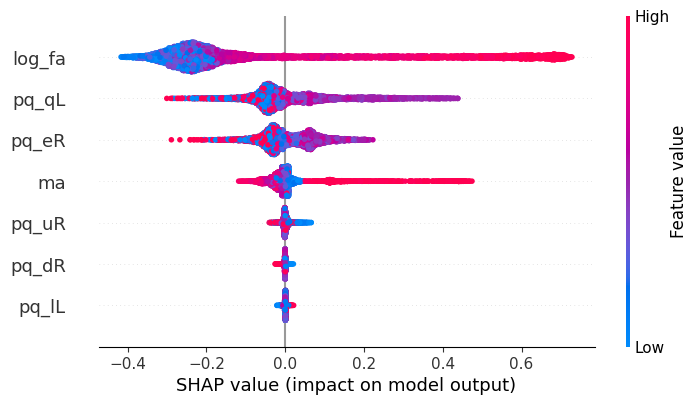

Bar plot...


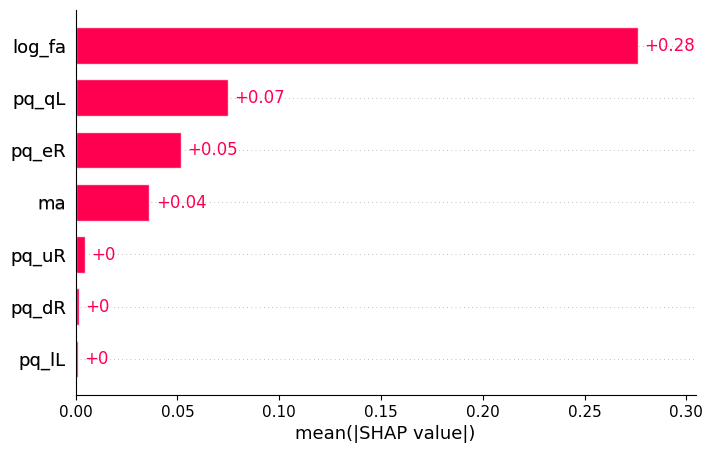

Waterfall plot...


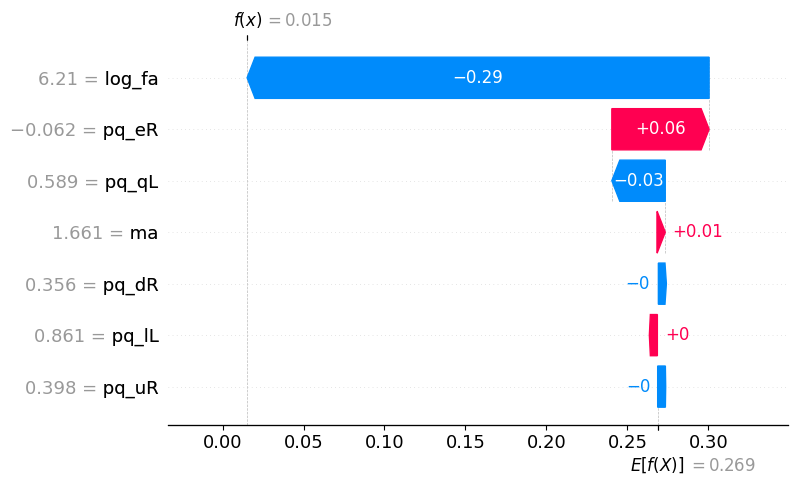

Scatter plots...


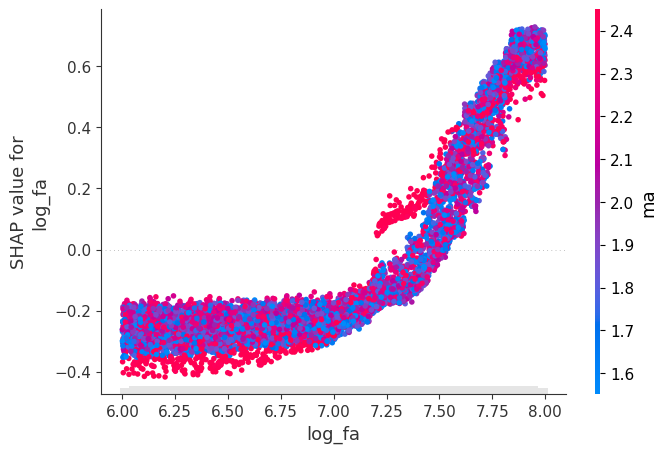

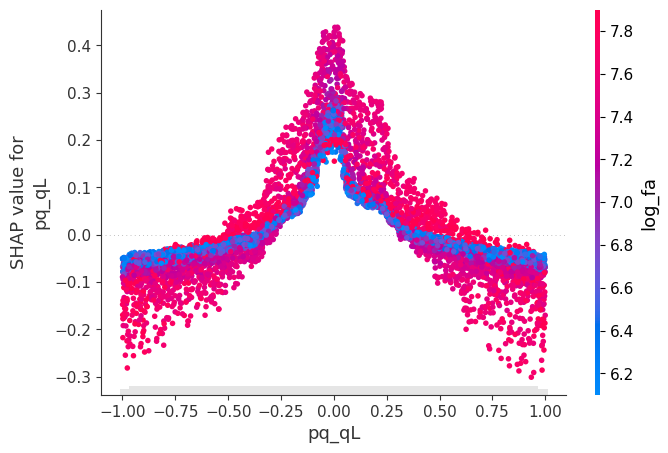

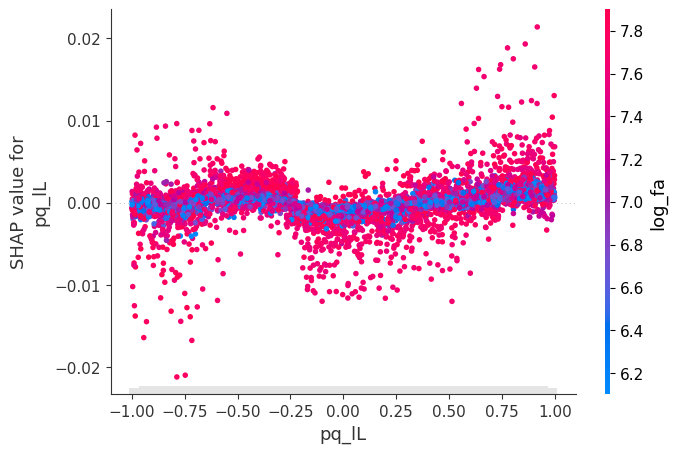

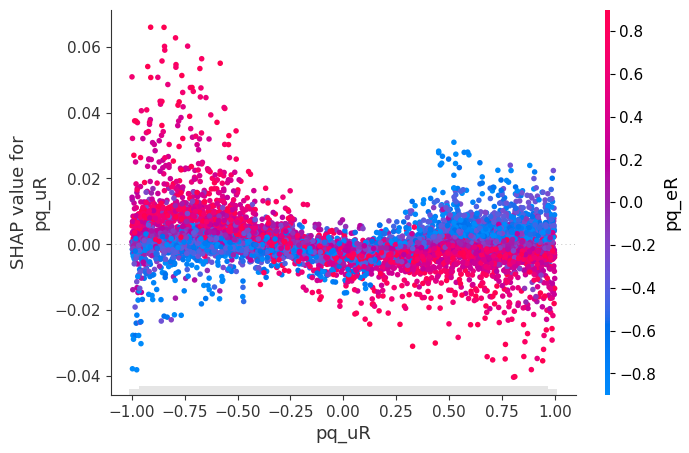

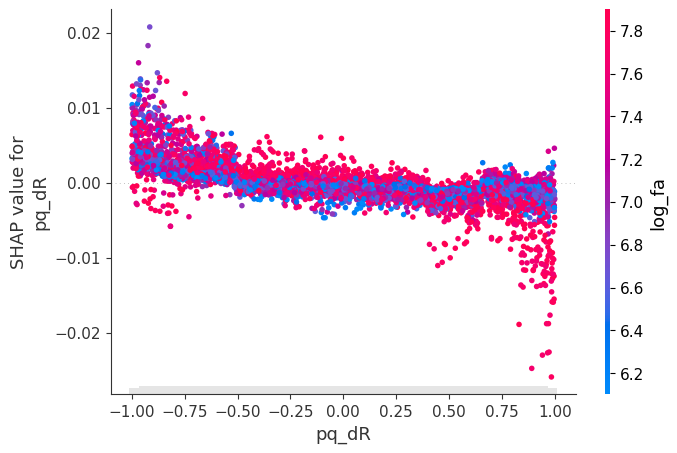

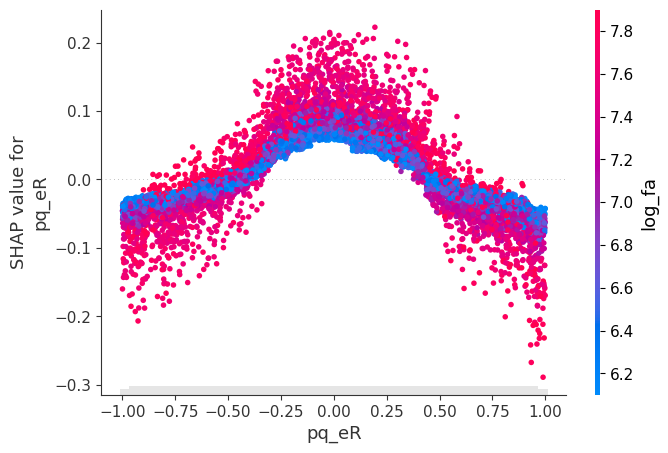

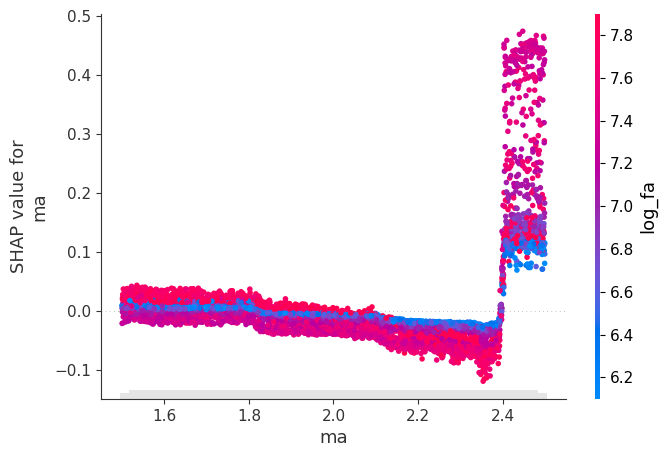

In [11]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP on the classifier: which PQ charges decide if a point is in the allowed region
df = pd.read_csv(DATASET_CSV)
features = FEATURES  # 7D includes 'ma'
X = df[features]

model = xgb.XGBRegressor()
model.load_model(CLF_PATH)
print("Classifier loaded.")

# Permutation explainer
explainer = shap.Explainer(model.predict, X)
shap_values = explainer(X)

# Beeswarm
print("Beeswarm plot...")
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values)

# Global importance (bar)
print("Bar plot...")
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values)

# Waterfall (point 0)
print("Waterfall plot...")
shap.plots.waterfall(shap_values[0])

# Dependence plots
print("Scatter plots...")
for col in features:
    shap.plots.scatter(shap_values[:, col], color=shap_values)

## <a id="sec-5"></a>§5. MCMC posterior + corner plot

Posterior sampling with **`emcee`** (`EnsembleSampler`, 128 walkers,
`DEMove`/`DESnookerMove` moves), as in the tutorial's `04_sampling.ipynb`.

**Posterior:**

$$
\log p(\theta) = \underbrace{-\tfrac12\,\widehat{\chi^2}_{\rm REG}(\theta)}_{\text{likelihood}}
\;+\; \underbrace{\log\pi(\theta)}_{\text{flat prior}}
\;-\; \underbrace{\mathrm{softplus}\!\big((0.5-\hat p_{\rm CLF})/0.04\big)}_{\text{wall}}
$$

- **Likelihood**: $-\tfrac12\,\chi^2$ from the **regressor** (not the sigmoid).
- **Wall**: the classifier holds the walkers back outside the allowed region.
- **Initialization**: the lowest-$\chi^2$ points of the dataset (near the mode).
- **Convergence**: by the autocorrelation time $\tau$ (runs until
  $50\tau < N_{\rm steps}$ and $\tau$ is stable); then `discard = 2\tau`,
  `thin = 0.5\tau`.

**Two corner plots:**
1. **UV space** — the 7 model parameters ($\log f_a$, the 5 PQ charges, $m_a$).
2. **Derived physical observables** ($\log f_a$, $m_a$, $|c_V^{sb}|$, $|c_A^{\mu\mu}|$,
   $|c_G|$, $\log c\tau$, $\log\mathrm{BR}(B^+\to K^+a)$), computed in parallel with
   `alpaca` over a **random subsample** of the posterior — this is the plot
   comparable to the professor's.

Contours at levels $[0.393, 0.864]$ (1σ/2σ of a 2D Gaussian) and `smooth=1.5`.

Posterior exists -- loading /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/datasets/posterior_samples_uv_v2.csv


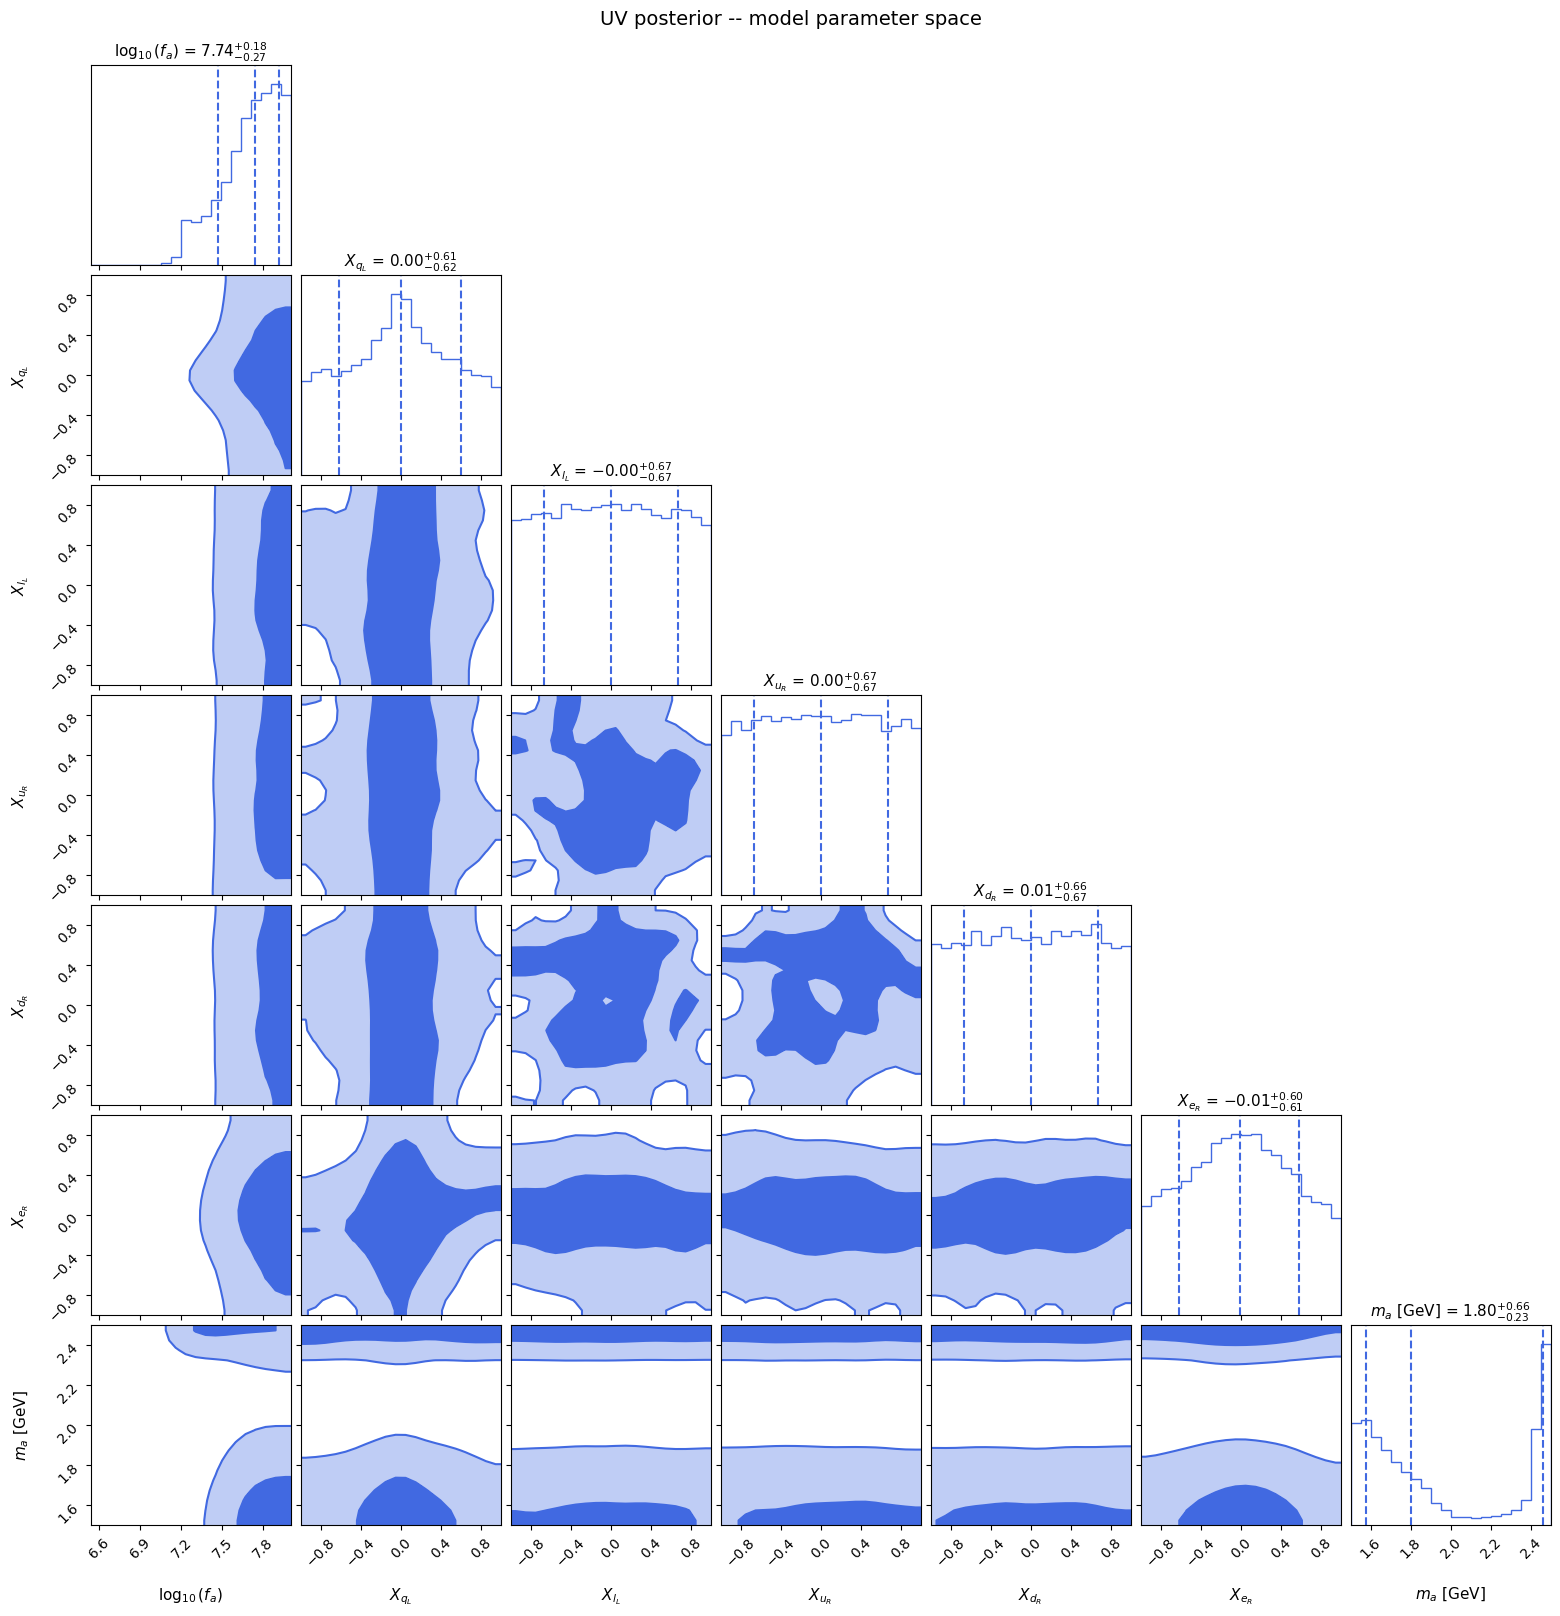

UV corner saved to /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/figures/corner_plot_uv_v2.png
Physical posterior exists -- loading /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/datasets/posterior_samples_uv_v2_theory.csv


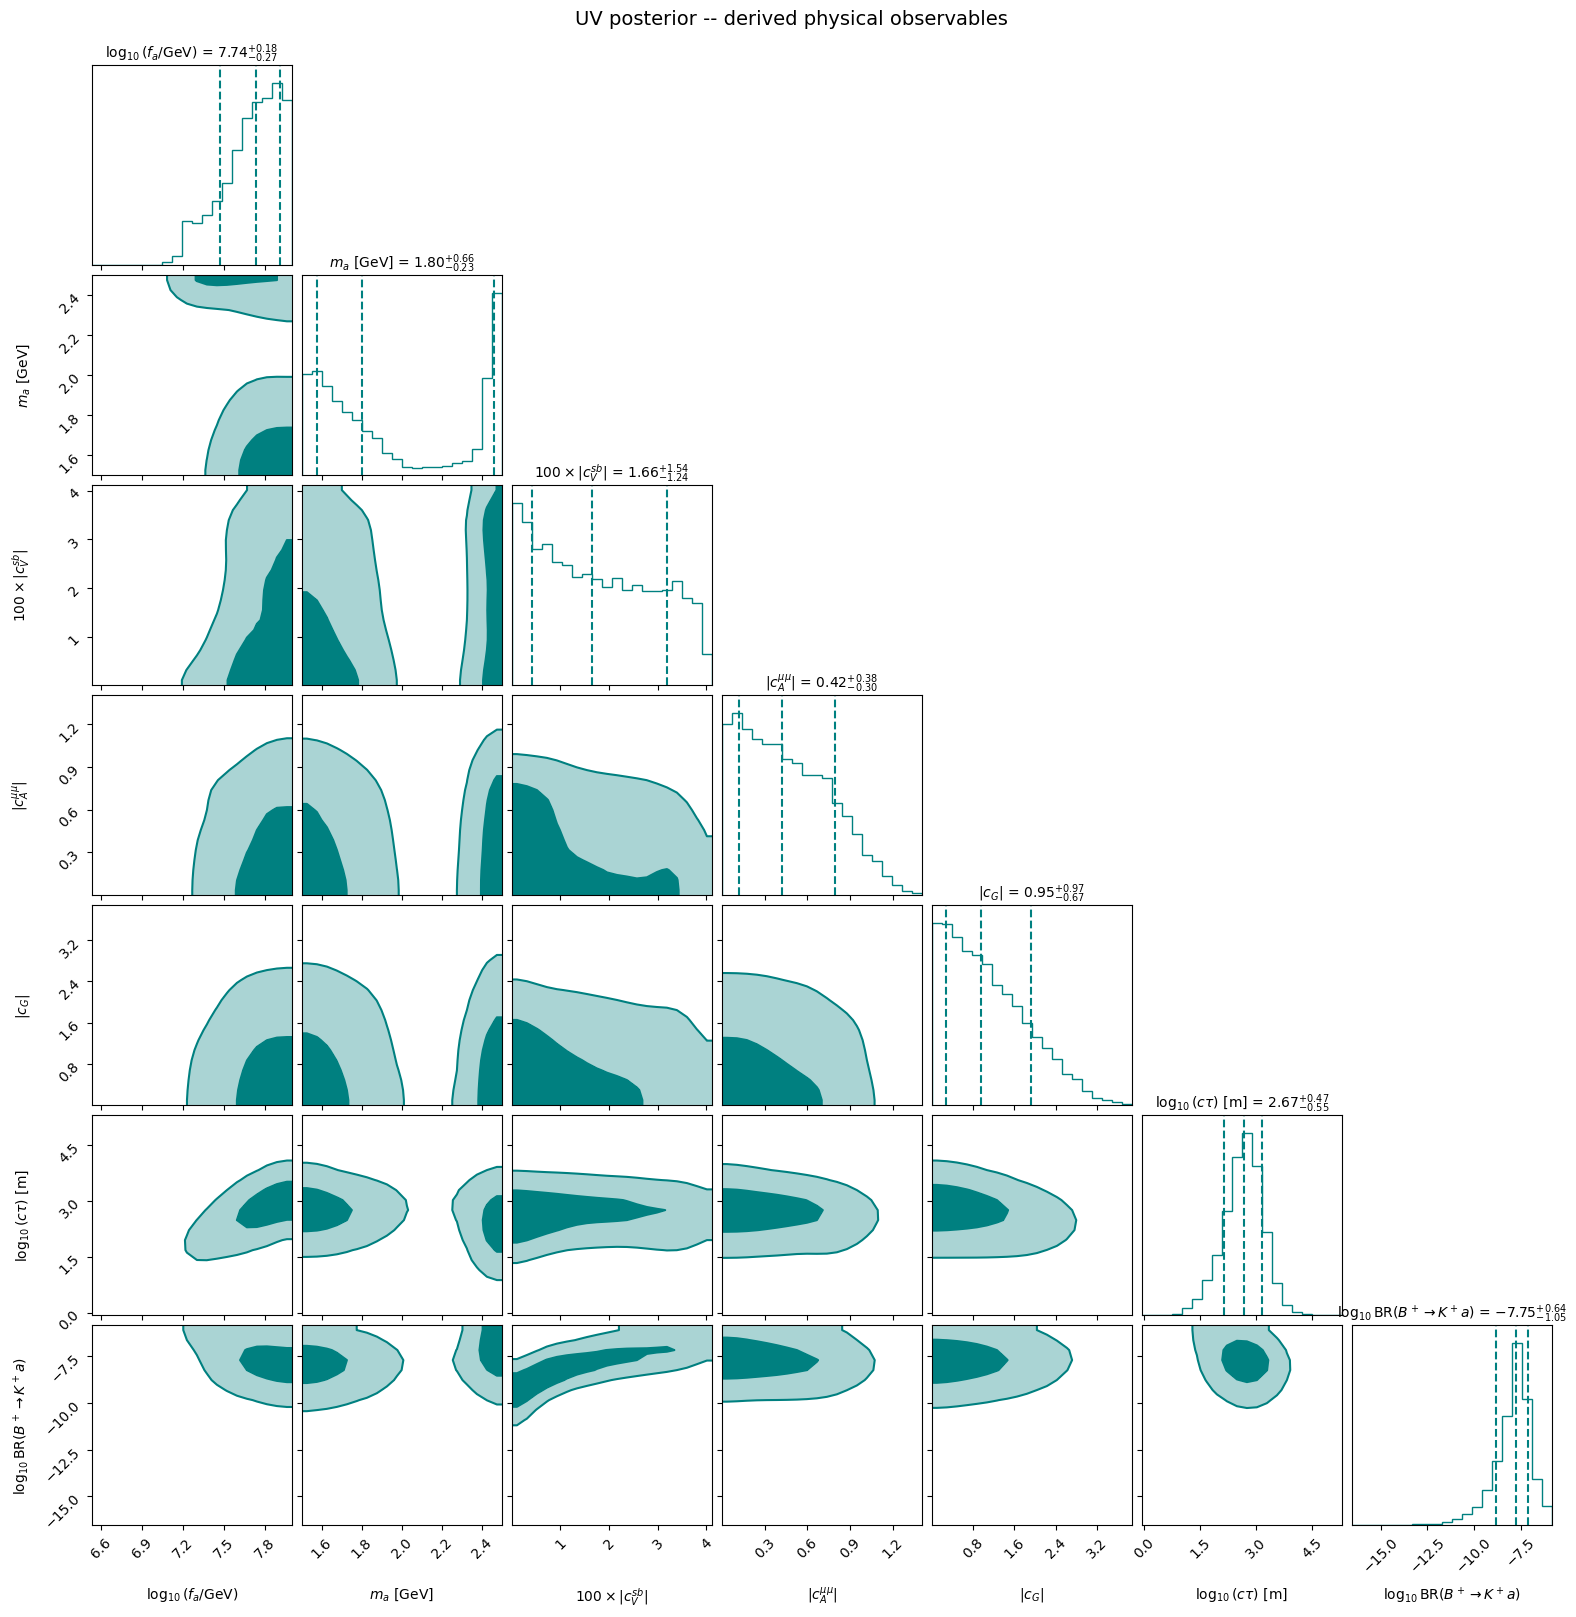

Physical corner saved to /home/aleja/repos/PhysicsML/AlpsML/outputs/paper/figures/corner_plot_uv_v2_phys.png


In [12]:
import numpy as np
import pandas as pd
import xgboost as xgb
import corner
import emcee
import matplotlib.pyplot as plt
import multiprocessing as mp
import time
import warnings

# Posterior:
#   log_posterior(x) = -0.5 * REG(x)      <- likelihood from the raw-chi2 regressor
#                      + flat prior        <- flat box prior
#                      - penalty(CLF(x))   <- soft wall from the classifier
# The likelihood comes from REG (raw chi2), not the sigmoid; CLF is only a wall.

clf = xgb.XGBRegressor(); clf.load_model(CLF_PATH)   # sigmoid(chi2) in [0,1]
reg = xgb.XGBRegressor(); reg.load_model(REG_PATH)   # raw chi2

_features = FEATURES  # 7D
_L = np.array([6.0, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, MA_MIN])
_H = np.array([8.0, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, MA_MAX])
ndim = len(_features)


def _softplus(x):
    """Stable log(1+e^x)."""
    return np.logaddexp(0.0, x)


def log_posterior(theta):
    """Vectorized: theta (n, ndim) -> log_prob (n,) for emcee vectorize=True."""
    theta = np.atleast_2d(theta).astype(np.float32)
    out = np.full(theta.shape[0], -np.inf, dtype=float)
    in_box = np.all((theta >= _L) & (theta <= _H), axis=1)
    if in_box.any():
        t = theta[in_box]
        chi2  = reg.predict(t)              # raw chi2 (regressor)
        p_all = clf.predict(t)              # sigmoid allowed/excluded
        log_lh  = -0.5 * chi2               # likelihood
        penalty = _softplus((0.5 - p_all) / 0.04)   # wall: p<0.5 -> excluded
        out[in_box] = log_lh - penalty      # flat prior inside the box
    return out


# Initial positions: the lowest-chi2 points of the dataset (near the mode)
_df_seed = pd.read_csv(DATASET_CSV)
_df_seed = _df_seed[np.isfinite(_df_seed['chi2'])]
nwalkers = 128
_seed = _df_seed.nsmallest(nwalkers, 'chi2')[_features].values
_rng = np.random.default_rng(42)
p0 = _seed + 1e-3 * (_H - _L) * _rng.normal(size=_seed.shape)
p0 = np.clip(p0, _L + 1e-9, _H - 1e-9)


# Run / load MCMC
if not FORCE_MCMC and POSTERIOR_CSV.exists():
    print(f"Posterior exists -- loading {POSTERIOR_CSV}")
    flat_samples = pd.read_csv(POSTERIOR_CSV).values
else:
    print(f"Running emcee ({nwalkers} walkers, vectorized)...")
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_posterior, vectorize=True,
        moves=[(emcee.moves.DEMove(), 0.8), (emcee.moves.DESnookerMove(), 0.2)],
    )
    max_n = 30_000
    old_tau = np.inf
    t0 = time.time()
    for _ in sampler.sample(p0, iterations=max_n, progress=True):
        if sampler.iteration % 200:
            continue
        tau = sampler.get_autocorr_time(tol=0)
        # Converged when chain > 50*tau and tau is stable to 1%
        converged = np.all(tau * 50 < sampler.iteration)
        converged &= np.all(np.abs(old_tau - tau) / tau < 0.01)
        old_tau = tau
        if converged:
            break

    tau = sampler.get_autocorr_time(tol=0)
    burnin = int(2 * np.max(tau))
    thinby = max(1, int(0.5 * np.min(tau)))
    flat_samples = sampler.get_chain(discard=burnin, thin=thinby, flat=True)
    acc = float(np.mean(sampler.acceptance_fraction))
    print(f"\n  steps={sampler.iteration}  tau_max={np.max(tau):.1f}  "
          f"burn-in={burnin}  thin={thinby}  acc={acc:.3f}")
    print(f"  samples (after burn-in + thin): {len(flat_samples):,}")

    pd.DataFrame(flat_samples, columns=_features).to_csv(POSTERIOR_CSV, index=False)
    print(f"  Saved: {POSTERIOR_CSV}")


# Corner plot -- UV space (model parameters)
corner_labels = [
    r"$\log_{10}(f_a)$", r"$X_{q_L}$", r"$X_{l_L}$",
    r"$X_{u_R}$", r"$X_{d_R}$", r"$X_{e_R}$", r"$m_a$ [GeV]"
]
fig1 = corner.corner(
    flat_samples, labels=corner_labels,
    show_titles=True, title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    color="royalblue", smooth=1.5,
    levels=[0.393, 0.864],   # 1-sigma and 2-sigma for a 2D Gaussian
    fill_contours=True, plot_datapoints=False,
    label_kwargs={"fontsize": 11}, title_kwargs={"fontsize": 11},
)
plt.suptitle("UV posterior -- model parameter space", fontsize=14, y=1.01)
plt.savefig(CORNER_PNG, dpi=300, bbox_inches='tight')
plt.show()
print(f"UV corner saved to {CORNER_PNG}")


# Corner plot -- derived physical observables:
# log10(fa), ma, 100*|c_Vsb|, |c_Amm|, |cG|, log10(ctau)[m], log10 BR(B+->K+a),
# computed in parallel over a random subsample of the posterior.
from alpaca.uvmodels import PQChargedModel
from alpaca.decays.alp_decays.branching_ratios import total_decay_width
from alpaca.decays.decays import branching_ratio
from alpaca.constants import hbarc_GeVnm

try:
    _CTX = mp.get_context('fork')
except ValueError:
    _CTX = mp.get_context()


def _derive_row(row):
    logfa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma = row
    fa = 10**logfa
    fa_scale = 4 * np.pi * fa
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            uv_model = PQChargedModel('non-universal model', {
                'qL': [0, 0, pq_qL], 'lL': [0, 0, pq_lL],
                'uR': pq_uR, 'dR': pq_dR, 'eR': pq_eR,
            })
            c = uv_model.get_couplings({}, fa_scale)
            clow = c.match_run(max(float(ma), 2.0), 'RL_below')
            c_Vsb = abs(complex(clow['cdL'][1, 2] + clow['cdR'][1, 2]))
            c_Amm = abs(complex(clow['ceR'][1, 1] - clow['ceL'][1, 1]))
            cG    = abs(float(clow['cG']))
            dw_dict = total_decay_width(float(ma), c, fa)
            dw_SM = float(dw_dict.get('DW_SM', 0.0))
            if dw_SM < 1e-50:
                log10_ctau = np.nan
            else:
                ctau_m = float(1e-7 * float(hbarc_GeVnm) / dw_SM) / 100.0
                log10_ctau = np.log10(ctau_m) if ctau_m > 0 else np.nan
            br = float(branching_ratio('B+ -> K+ a', float(ma), c, fa))
            log10_br = np.log10(max(br, 1e-20))
            return (logfa, ma, 100.0 * c_Vsb, c_Amm, cG, log10_ctau, log10_br)
    except Exception:
        return (logfa, ma, np.nan, np.nan, np.nan, np.nan, np.nan)


if not FORCE_MCMC and POSTERIOR_CSV_THEORY.exists():
    print(f"Physical posterior exists -- loading {POSTERIOR_CSV_THEORY}")
    theory_df = pd.read_csv(POSTERIOR_CSV_THEORY)
else:
    N_PHYS = min(15_000, len(flat_samples))
    idx = np.random.default_rng(99).choice(len(flat_samples), N_PHYS, replace=False)
    subset = flat_samples[idx]
    print(f"Computing physical observables for {N_PHYS} random samples "
          f"({N_CORES} cores)...")
    t0 = time.time()
    with _CTX.Pool(processes=N_CORES) as pool:
        rows = pool.map(_derive_row, [tuple(r) for r in subset], chunksize=8)
    theory_df = pd.DataFrame(rows, columns=[
        'log_fa', 'ma', 'c_Vsb_x100', 'c_Amm', 'cG', 'log10_ctau_m', 'log10_BR_BKa'
    ]).dropna().reset_index(drop=True)
    print(f"  {len(theory_df)}/{N_PHYS} valid in {time.time()-t0:.0f}s")
    theory_df.to_csv(POSTERIOR_CSV_THEORY, index=False)
    print(f"  Saved: {POSTERIOR_CSV_THEORY}")

# Corner plot of physical observables
phys_labels = [
    r"$\log_{10}(f_a/\mathrm{GeV})$",
    r"$m_a\ [\mathrm{GeV}]$",
    r"$100\times|c_V^{sb}|$",
    r"$|c_A^{\mu\mu}|$",
    r"$|c_G|$",
    r"$\log_{10}(c\tau)\ [\mathrm{m}]$",
    r"$\log_{10}\mathrm{BR}(B^+\to K^+a)$",
]
phys_data = theory_df[[
    'log_fa', 'ma', 'c_Vsb_x100', 'c_Amm', 'cG', 'log10_ctau_m', 'log10_BR_BKa'
]].values

fig2 = corner.corner(
    phys_data, labels=phys_labels,
    show_titles=True, title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    color="teal", smooth=1.5,
    levels=[0.393, 0.864],
    fill_contours=True, plot_datapoints=False,
    label_kwargs={"fontsize": 10}, title_kwargs={"fontsize": 10},
)
plt.suptitle("UV posterior -- derived physical observables", fontsize=14, y=1.01)
plt.savefig(CORNER_PHYS_PNG, dpi=300, bbox_inches='tight')
plt.show()
print(f"Physical corner saved to {CORNER_PHYS_PNG}")